In [2]:
import sklearn

print(sklearn.__version__)
print(sklearn.__file__)

1.9.0
d:\Enterprise Retail Intelligence Platform\retailenv\Lib\site-packages\sklearn\__init__.py


In [3]:
import numpy as np
import scipy
import sklearn

print("NumPy :", np.__version__)
print("SciPy :", scipy.__version__)

from sklearn.tree import DecisionTreeRegressor

print("DecisionTree Imported Successfully")

NumPy : 2.4.6
SciPy : 1.17.1
DecisionTree Imported Successfully


In [4]:
from sklearn.ensemble import GradientBoostingRegressor

print("GradientBoosting Imported Successfully")

GradientBoosting Imported Successfully


In [5]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
d:\Enterprise Retail Intelligence Platform\notebooks


In [8]:
import os

print(os.listdir(".."))

['dashboard', 'data', 'docs', 'images', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'retailenv', 'src']


In [9]:
import os

print(os.listdir("../data"))

['calendar.csv', 'dashboard_prediction_features.csv', 'dashboard_prediction_inputs.csv', 'features', 'processed', 'raw', 'sales_train_evaluation.csv', 'sales_train_validation.csv', 'sample_submission.csv', 'sell_prices.csv']


In [10]:
import pandas as pd

test_df = pd.read_csv("../data/sales_train_validation.csv", nrows=5)

print(test_df.shape)
test_df.head()

(5, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [11]:
import pandas as pd

sales_df = pd.read_csv(
    "../data/sales_train_validation.csv",
    nrows=5000
)

print(sales_df.shape)

(5000, 1919)


In [12]:
prices_df = pd.read_csv(
    "../data/sell_prices.csv",
    nrows=500000
)

print(prices_df.shape)

(500000, 4)


In [13]:
# ==========================================================
# Load Calendar Dataset
# ==========================================================

calendar_df = pd.read_csv("../data/calendar.csv")

print(calendar_df.shape)
calendar_df.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [14]:
# ==========================================================
# Create ML Dataset
# ==========================================================

# Last 30 days of sales
day_cols = [f"d_{i}" for i in range(1884, 1914)]

ml_df = sales_df[
    ["item_id", "dept_id", "cat_id", "store_id", "state_id"] + day_cols
].copy()

print(ml_df.shape)
ml_df.head()

(5000, 35)


,item_id,dept_id,cat_id,store_id,state_id,d_1884,d_1885,d_1886,d_1887,d_1888,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,1,1,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,6,6,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,4,...,2,1,1,0,1,1,2,2,2,4


In [15]:
# ==========================================================
# Create Target Variable
# ==========================================================

X = ml_df.drop(columns=["d_1913"])

y = ml_df["d_1913"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 34)
y Shape: (5000,)


In [16]:
# ==========================================================
# Create ML Dataset
# ==========================================================

# Last 30 days of sales
day_cols = [f"d_{i}" for i in range(1884, 1914)]

ml_df = sales_df[
    ["item_id", "dept_id", "cat_id", "store_id", "state_id"] + day_cols
].copy()

print("ML Dataset Shape:", ml_df.shape)
ml_df.head()

ML Dataset Shape: (5000, 35)


,item_id,dept_id,cat_id,store_id,state_id,d_1884,d_1885,d_1886,d_1887,d_1888,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,1,1,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,6,6,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,4,...,2,1,1,0,1,1,2,2,2,4


In [17]:
# ==========================================================
# Create Features and Target
# ==========================================================

X = ml_df.drop(columns=["d_1913"])
y = ml_df["d_1913"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 34)
y Shape: (5000,)


In [18]:
# ==========================================================
# Encode Categorical Features
# ==========================================================

from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("Encoding Completed!")
X.head()

Encoding Completed!


,item_id,dept_id,cat_id,store_id,state_id,d_1884,d_1885,d_1886,d_1887,d_1888,...,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912
0,1437,3,1,0,0,1,1,1,0,0,...,1,1,3,0,1,1,1,3,0,1
1,1438,3,1,0,0,1,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1439,3,1,0,0,1,0,0,0,0,...,2,2,1,2,1,1,1,0,1,1
3,1440,3,1,0,0,6,6,0,0,0,...,0,1,0,5,4,1,0,1,3,7
4,1441,3,1,0,0,0,0,1,0,4,...,1,2,1,1,0,1,1,2,2,2


In [19]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (4000, 34)
X_test Shape : (1000, 34)
y_train Shape: (4000,)
y_test Shape : (1000,)


In [20]:
# ==========================================================
# Train Random Forest Regressor
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [21]:
# ==========================================================
# Predict on Test Data
# ==========================================================

y_pred = rf_model.predict(X_test)

print("Prediction Shape:", y_pred.shape)
print(y_pred[:10])   # First 10 predictions

Prediction Shape: (1000,)
[ 0.77 23.03  2.42  0.97  3.8   0.77  0.98  0.83  1.53  0.58]


In [22]:
# ==========================================================
# Evaluate Random Forest Model
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== Random Forest Performance ==========")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R² Score  : {r2:.4f}")

========== Random Forest Performance ==========
MAE       : 1.1944
RMSE      : 1.8773
R² Score  : 0.6635


In [23]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
27  d_1906    0.218784
33  d_1912    0.150887
13  d_1892    0.132661
28  d_1907    0.039397
20  d_1899    0.035645
29  d_1908    0.034449
11  d_1890    0.030395
31  d_1910    0.028118
14  d_1893    0.027814
30  d_1909    0.020625


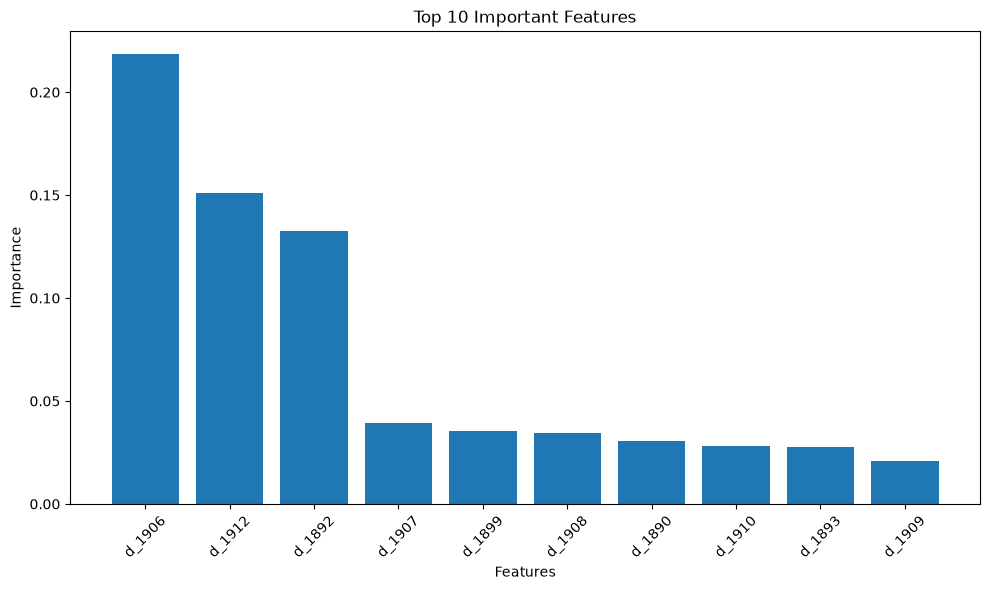

In [24]:
# ==========================================================
# Top 10 Feature Importance Plot
# ==========================================================

import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.bar(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# ==========================================================
# Import XGBoost
# ==========================================================

from xgboost import XGBRegressor

print("XGBoost Imported Successfully!")

XGBoost Imported Successfully!


In [26]:
# ==========================================================
# Create XGBoost Regressor
# ==========================================================

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

print("XGBoost Model Created Successfully!")

XGBoost Model Created Successfully!


In [27]:
# ==========================================================
# Train XGBoost Model
# ==========================================================

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [28]:
# ==========================================================
# XGBoost Predictions
# ==========================================================

xgb_pred = xgb_model.predict(X_test)

print("Prediction Shape:", xgb_pred.shape)
print("First 10 Predictions:")
print(xgb_pred[:10])

Prediction Shape: (1000,)
First 10 Predictions:
[ 0.36503008 23.51935     2.6786668   1.027906    3.3244395   0.50554395
  0.72665185  0.7784188   1.2049503   0.23185231]


In [29]:
# ==========================================================
# Evaluate XGBoost Model
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("========== XGBoost Performance ==========")
print(f"MAE      : {xgb_mae:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")
print(f"R² Score : {xgb_r2:.4f}")

========== XGBoost Performance ==========
MAE      : 1.2005
RMSE     : 1.8616
R² Score : 0.6691


In [30]:
# ==========================================================
# Model Performance Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae, xgb_mae],
    "RMSE": [rmse, xgb_rmse],
    "R2 Score": [r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,1.194370,1.877344,0.663461
1,XGBoost,1.200512,1.861643,0.669067


In [31]:
# ==========================================================
# XGBoost Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
display(feature_importance.head(10))

Top 10 Important Features:


,Feature,Importance
27,d_1906,0.201447
33,d_1912,0.175773
13,d_1892,0.120835
11,d_1890,0.048126
29,d_1908,0.033906
19,d_1898,0.030581
20,d_1899,0.028007
28,d_1907,0.027701
30,d_1909,0.025301
31,d_1910,0.023352


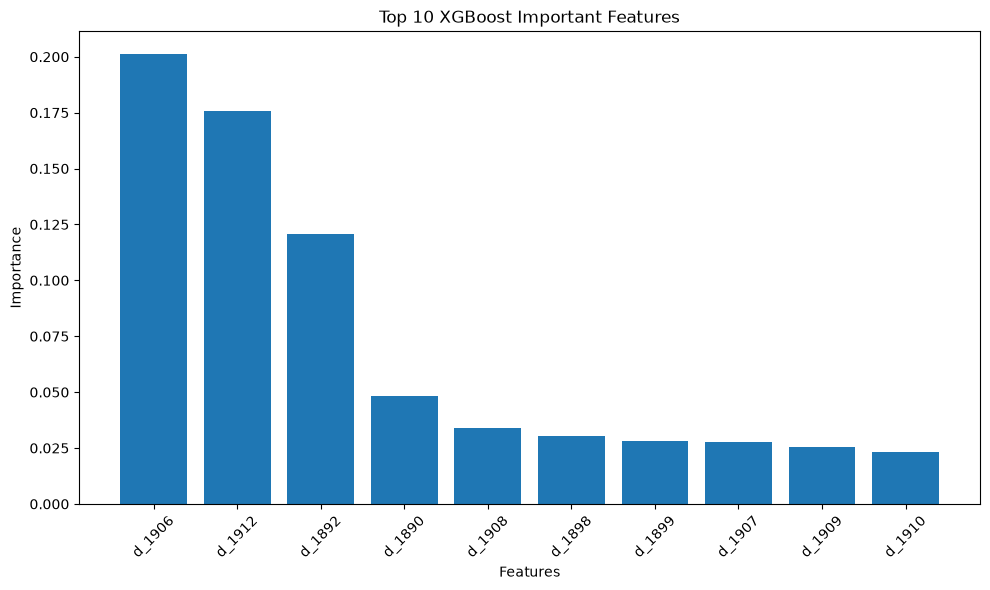

In [32]:
# ==========================================================
# XGBoost Feature Importance Visualization
# ==========================================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 XGBoost Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# ==========================================================
# Save XGBoost Model
# ==========================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgboost_sales_model.pkl")

print("XGBoost Model Saved Successfully!")

XGBoost Model Saved Successfully!


In [34]:
# ==========================================================
# Save Random Forest Model
# ==========================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/random_forest_sales_model.pkl")

print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!


In [35]:
# ==========================================================
# Final Model Comparison
# ==========================================================

final_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae, xgb_mae],
    "RMSE": [rmse, xgb_rmse],
    "R2 Score": [r2, xgb_r2]
})

final_comparison = final_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("========== FINAL MODEL COMPARISON ==========")
display(final_comparison)

========== FINAL MODEL COMPARISON ==========


,Model,MAE,RMSE,R2 Score
0,XGBoost,1.200512,1.861643,0.669067
1,Random Forest,1.194370,1.877344,0.663461


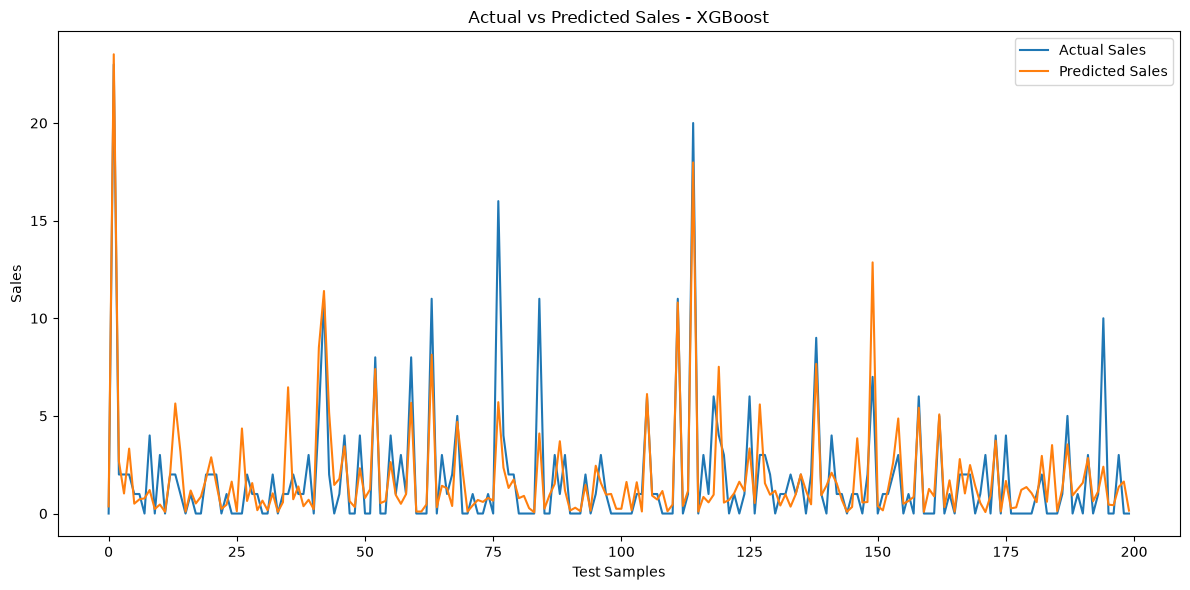

In [36]:
# ==========================================================
# Actual vs Predicted Sales - XGBoost
# ==========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:200],
    label="Actual Sales"
)

plt.plot(
    xgb_pred[:200],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales - XGBoost")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

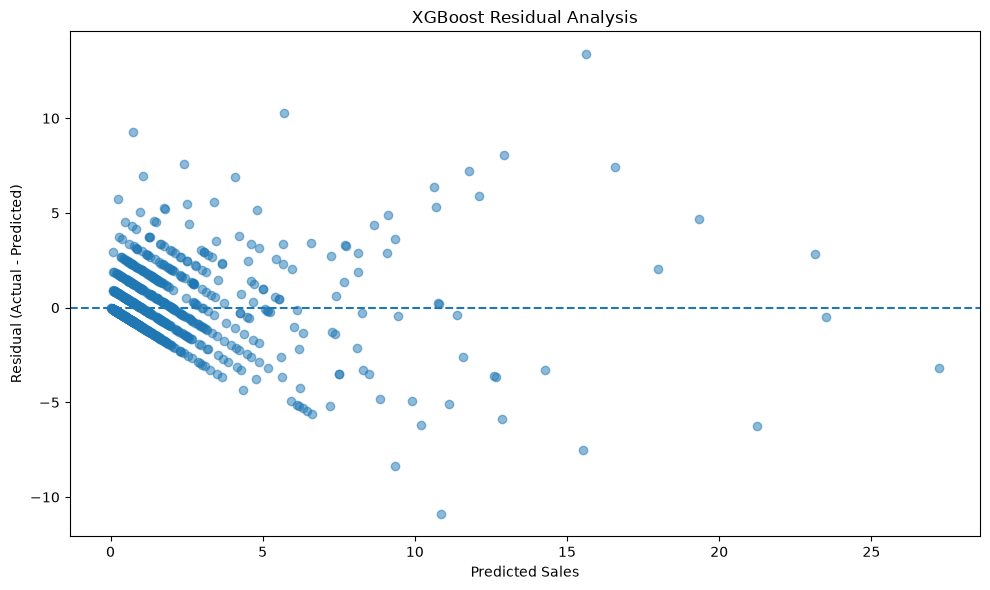

In [37]:
# ==========================================================
# XGBoost Residual Analysis
# ==========================================================

residuals = y_test.values - xgb_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("XGBoost Residual Analysis")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================================
# Actual vs Predicted Average Sales
# ==========================================================

actual_avg = y_test.mean()
predicted_avg = xgb_pred.mean()

print("========== AVERAGE SALES COMPARISON ==========")
print(f"Actual Average Sales    : {actual_avg:.4f}")
print(f"Predicted Average Sales : {predicted_avg:.4f}")

difference = abs(actual_avg - predicted_avg)

print(f"Absolute Difference     : {difference:.4f}")

========== AVERAGE SALES COMPARISON ==========
Actual Average Sales    : 1.8570
Predicted Average Sales : 1.7850
Absolute Difference     : 0.0720


In [39]:
# ==========================================================
# Save XGBoost Feature Names
# ==========================================================

import joblib

feature_columns = list(X_train.columns)

joblib.dump(
    feature_columns,
    "../models/xgboost_feature_columns.pkl"
)

print("Feature Columns Saved Successfully!")
print("Number of Features:", len(feature_columns))
print("Features:", feature_columns)

Feature Columns Saved Successfully!
Number of Features: 34
Features: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1884', 'd_1885', 'd_1886', 'd_1887', 'd_1888', 'd_1889', 'd_1890', 'd_1891', 'd_1892', 'd_1893', 'd_1894', 'd_1895', 'd_1896', 'd_1897', 'd_1898', 'd_1899', 'd_1900', 'd_1901', 'd_1902', 'd_1903', 'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912']


In [40]:
# ==========================================================
# Load Saved XGBoost Model
# ==========================================================

import joblib

loaded_xgb_model = joblib.load(
    "../models/xgboost_sales_model.pkl"
)

print("Saved XGBoost Model Loaded Successfully!")
print("Model Type:", type(loaded_xgb_model))

Saved XGBoost Model Loaded Successfully!
Model Type: <class 'xgboost.sklearn.XGBRegressor'>


In [41]:
# ==========================================================
# Test Saved XGBoost Model
# ==========================================================

loaded_predictions = loaded_xgb_model.predict(X_test)

print("Prediction Successful!")
print("Prediction Shape:", loaded_predictions.shape)
print("First 10 Predictions:")
print(loaded_predictions[:10])

Prediction Successful!
Prediction Shape: (1000,)
First 10 Predictions:
[ 0.36503008 23.51935     2.6786668   1.027906    3.3244395   0.50554395
  0.72665185  0.7784188   1.2049503   0.23185231]


In [42]:
# ==========================================================
# Verify Saved Model Predictions
# ==========================================================

import numpy as np

difference = np.max(
    np.abs(xgb_pred - loaded_predictions)
)

print("Maximum Prediction Difference:", difference)

if difference < 1e-10:
    print("✅ Saved model predictions match the original model!")
else:
    print("⚠️ Predictions are slightly different.")

Maximum Prediction Difference: 0.0
✅ Saved model predictions match the original model!


In [43]:
# ==========================================================
# XGBoost Sales Prediction Function
# ==========================================================

def predict_sales(input_data):
    """
    Generate sales predictions using the saved XGBoost model.
    """

    predictions = loaded_xgb_model.predict(input_data)

    return predictions


print("Prediction Function Created Successfully!")

Prediction Function Created Successfully!


In [44]:
# ==========================================================
# Test Prediction Function
# ==========================================================

test_predictions = predict_sales(X_test)

print("Prediction Function Tested Successfully!")
print("Prediction Shape:", test_predictions.shape)
print("First 10 Predictions:")
print(test_predictions[:10])

Prediction Function Tested Successfully!
Prediction Shape: (1000,)
First 10 Predictions:
[ 0.36503008 23.51935     2.6786668   1.027906    3.3244395   0.50554395
  0.72665185  0.7784188   1.2049503   0.23185231]


In [45]:
# ==========================================================
# Single Record Sales Prediction
# ==========================================================

# Select one record from the test dataset
single_record = X_test.iloc[[0]]

# Generate prediction
single_prediction = predict_sales(single_record)

print("Single Record Prediction Successful!")
print("Predicted Sales:", round(single_prediction[0], 4))

Single Record Prediction Successful!
Predicted Sales: 0.365


In [46]:
# ==========================================================
# Save Prediction Pipeline
# ==========================================================

import joblib

# Save the prediction function components
pipeline = {
    "model": loaded_xgb_model,
    "features": feature_columns
}

joblib.dump(
    pipeline,
    "../models/xgboost_prediction_pipeline.pkl"
)

print("Prediction Pipeline Saved Successfully!")

Prediction Pipeline Saved Successfully!


In [47]:
# ==========================================================
# Load Saved Prediction Pipeline
# ==========================================================

import joblib

loaded_pipeline = joblib.load(
    "../models/xgboost_prediction_pipeline.pkl"
)

loaded_model = loaded_pipeline["model"]
loaded_features = loaded_pipeline["features"]

print("Prediction Pipeline Loaded Successfully!")
print("Model Type:", type(loaded_model))
print("Number of Features:", len(loaded_features))
print("Features Match:", loaded_features == feature_columns)

Prediction Pipeline Loaded Successfully!
Model Type: <class 'xgboost.sklearn.XGBRegressor'>
Number of Features: 34
Features Match: True


In [48]:
# ==========================================================
# Test Loaded Prediction Pipeline
# ==========================================================

pipeline_predictions = loaded_model.predict(
    X_test[loaded_features]
)

print("Pipeline Prediction Successful!")
print("Prediction Shape:", pipeline_predictions.shape)
print("First 10 Predictions:")
print(pipeline_predictions[:10])

Pipeline Prediction Successful!
Prediction Shape: (1000,)
First 10 Predictions:
[ 0.36503008 23.51935     2.6786668   1.027906    3.3244395   0.50554395
  0.72665185  0.7784188   1.2049503   0.23185231]


In [49]:
# ==========================================================
# Inspect One Prediction Input
# ==========================================================

single_input = X_test.iloc[[0]][loaded_features]

print("Single Prediction Input:")
display(single_input)

Single Prediction Input:


,item_id,dept_id,cat_id,store_id,state_id,d_1884,d_1885,d_1886,d_1887,d_1888,...,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912
1501,2938,6,2,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [50]:
# ==========================================================
# User-Friendly Sales Prediction
# ==========================================================

def predict_single_sales(input_row):
    """
    Predict sales for a single prepared record.
    """

    # Ensure correct feature order
    input_row = input_row[loaded_features]

    # Generate prediction
    prediction = loaded_model.predict(input_row)

    return float(prediction[0])


# Test with the single record
prediction = predict_single_sales(single_input)

print("Single Sales Prediction Successful!")
print(f"Predicted Sales: {prediction:.4f}")

Single Sales Prediction Successful!
Predicted Sales: 0.3650


In [51]:
# ==========================================================
# Create Lightweight Dashboard Data
# ==========================================================

dashboard_data = X_test[
    ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
].copy()

# Remove duplicate product/store combinations
dashboard_data = dashboard_data.drop_duplicates().reset_index(drop=True)

# Save lightweight dataset
dashboard_data.to_csv(
    "../data/dashboard_prediction_inputs.csv",
    index=False
)

print("Dashboard Input Data Created Successfully!")
print("Shape:", dashboard_data.shape)
display(dashboard_data.head())

Dashboard Input Data Created Successfully!
Shape: (1000, 5)


,item_id,dept_id,cat_id,store_id,state_id
0,2938,6,2,0,0
1,974,2,0,0,0
2,1041,2,0,0,0
3,2492,5,2,0,0
4,2142,5,2,0,0


In [52]:
# ==========================================================
# Verify Dashboard Input File
# ==========================================================

dashboard_test = pd.read_csv(
    "../data/dashboard_prediction_inputs.csv"
)

print("Dashboard Input File Loaded Successfully!")
print("Shape:", dashboard_test.shape)
print("Columns:", dashboard_test.columns.tolist())

display(dashboard_test.head())

Dashboard Input File Loaded Successfully!
Shape: (1000, 5)
Columns: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']


,item_id,dept_id,cat_id,store_id,state_id
0,2938,6,2,0,0
1,974,2,0,0,0
2,1041,2,0,0,0
3,2492,5,2,0,0
4,2142,5,2,0,0


In [53]:
# ==========================================================
# Recreate Feature List
# ==========================================================

features = [
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id',
    'd_1884',
    'd_1885',
    'd_1886',
    'd_1887',
    'd_1888',
    'd_1889',
    'd_1890',
    'd_1891',
    'd_1892',
    'd_1893',
    'd_1894',
    'd_1895',
    'd_1896',
    'd_1897',
    'd_1898',
    'd_1899',
    'd_1900',
    'd_1901',
    'd_1902',
    'd_1903',
    'd_1904',
    'd_1905',
    'd_1906',
    'd_1907',
    'd_1908',
    'd_1909',
    'd_1910',
    'd_1911',
    'd_1912'
]

print("Feature List Recreated Successfully!")
print("Number of Features:", len(features))

Feature List Recreated Successfully!
Number of Features: 34


In [54]:
# ==========================================================
# Save Complete Dashboard Prediction Features
# ==========================================================

dashboard_prediction_data = X_test[features].copy()

dashboard_prediction_data.to_csv(
    "../data/dashboard_prediction_features.csv",
    index=False
)

print("Complete Dashboard Prediction Data Saved Successfully!")
print("Shape:", dashboard_prediction_data.shape)
print("Number of Features:", len(dashboard_prediction_data.columns))

Complete Dashboard Prediction Data Saved Successfully!
Shape: (1000, 34)
Number of Features: 34


In [58]:
# Check whether the latest feature-engineered dataframe exists
# under another variable name

for name in list(globals().keys()):
    try:
        obj = globals()[name]
        if hasattr(obj, "shape") and obj.shape == (30490, 22):
            print("FOUND:", name, "→", obj.shape)
    except:
        pass

In [59]:
import pandas as pd

model_df = pd.read_csv("final_ml_dataset.csv")

print("Model dataset shape:", model_df.shape)

Model dataset shape: (30490, 22)


In [60]:
# Separate features and target

X = model_df.drop(columns=["d_1913"])
y = model_df["d_1913"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30490, 21)
y shape: (30490,)


In [61]:
print("Categorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(exclude=["object"]).columns.tolist())

Categorical columns:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

Numerical columns:
['lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'wm_yr_wk', 'wday', 'month', 'year', 'snap']


In [62]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so the original X remains unchanged
X_encoded = X.copy()

# Remove date because we already extracted useful calendar features
X_encoded = X_encoded.drop(columns=["date"])

# Categorical columns to encode
categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

# Store encoders
label_encoders = {}

# Apply Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("Encoding completed successfully!")
print("Encoded X shape:", X_encoded.shape)

Encoding completed successfully!
Encoded X shape: (30490, 20)


In [63]:
print(X_encoded.head())
print("\nData types:")
print(X_encoded.dtypes)

   item_id  dept_id  cat_id  store_id  state_id  lag_1  lag_7  lag_28  \
0     1437        3       1         0         0      1      0       1   
1     1438        3       1         0         0      0      0       1   
2     1439        3       1         0         0      1      2       0   
3     1440        3       1         0         0      7      5       6   
4     1441        3       1         0         0      2      1       0   

   rolling_mean_7  rolling_mean_28  wm_yr_wk  weekday  wday  month  year  \
0        1.000000         0.964286     11613        0     2      4  2016   
1        0.142857         0.107143     11613        0     2      4  2016   
2        1.000000         0.535714     11613        0     2      4  2016   
3        3.000000         1.964286     11613        0     2      4  2016   
4        1.285714         1.214286     11613        0     2      4  2016   

   event_name_1  event_type_1  event_name_2  event_type_2  snap  
0             0             0         

In [64]:
print("Number of unique dates:", model_df["date"].nunique())

print("\nDate range:")
print("Start:", model_df["date"].min())
print("End:", model_df["date"].max())

print("\nDates:")
print(model_df["date"].unique())

Number of unique dates: 1

Date range:
Start: 2016-04-24
End: 2016-04-24

Dates:
['2016-04-24']


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24392, 20)
X_test : (6098, 20)
y_train: (24392,)
y_test : (6098,)


In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [67]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred_rf[:10])

Predictions generated successfully!
First 10 predictions:
[0.72 0.36 0.35 2.13 0.02 0.46 5.27 0.58 2.03 0.53]


In [68]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 1.0965365693670057
RMSE: 1.9738926135563735
R²  : 0.7386532245902493


Gradient Boosting Regressor

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [70]:
# Predictions
y_pred_gb = gb_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [71]:
# Evaluate Gradient Boosting

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting Performance
-----------------------------
MAE : 1.06587856284971
RMSE: 1.9219013128863864
R²  : 0.7522393857137306


In [72]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [73]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [74]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Performance
-------------------
MAE : 1.0615200996398926
RMSE: 1.94568510968136
R²  : 0.7460693120956421


In [75]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [76]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create LightGBM model
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train
lgb_model.fit(X_train, y_train)

print("LightGBM training completed!")

LightGBM training completed!


In [77]:
y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM predictions generated!")

LightGBM predictions generated!


In [78]:
lgb_mae = mean_absolute_error(y_test, y_pred_lgb)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
lgb_r2 = r2_score(y_test, y_pred_lgb)

print("LightGBM Performance")
print("--------------------")
print("MAE :", lgb_mae)
print("RMSE:", lgb_rmse)
print("R²  :", lgb_r2)

LightGBM Performance
--------------------
MAE : 1.0730259469265904
RMSE: 2.0178029345009496
R²  : 0.7268962894238493


In [79]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [80]:
from catboost import CatBoostRegressor

# Create CatBoost model
cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

# Train
cat_model.fit(X_train, y_train)

print("CatBoost training completed!")

CatBoost training completed!


In [81]:
y_pred_cat = cat_model.predict(X_test)

print("CatBoost predictions generated!")

CatBoost predictions generated!


In [82]:
cat_mae = mean_absolute_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
cat_r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Performance")
print("--------------------")
print("MAE :", cat_mae)
print("RMSE:", cat_rmse)
print("R²  :", cat_r2)

CatBoost Performance
--------------------
MAE : 1.077829155738306
RMSE: 1.9390055785422131
R²  : 0.7478097923095601


In [83]:
print("Shape:", sales_df.shape)

print("\nFirst 10 columns:")
print(sales_df.columns[:10].tolist())

print("\nLast 10 columns:")
print(sales_df.columns[-10:].tolist())

Shape: (5000, 1919)

First 10 columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']

Last 10 columns:
['d_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [84]:
print("\nData types:")
print(sales_df.dtypes.head(10))


Data types:
id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
state_id    object
d_1          int64
d_2          int64
d_3          int64
d_4          int64
dtype: object


In [85]:
import numpy as np

# Select daily sales columns
daily_cols = [col for col in sales_df.columns if col.startswith("d_")]

print("Number of daily columns:", len(daily_cols))
print("First:", daily_cols[0])
print("Last:", daily_cols[-1])

Number of daily columns: 1913
First: d_1
Last: d_1913


In [86]:
# Historical sales matrix
sales_matrix = sales_df[daily_cols].values

print("Sales matrix shape:", sales_matrix.shape)

Sales matrix shape: (5000, 1913)


In [88]:
# ==========================================================
# LSTM Dataset Preparation
# ==========================================================

lookback = 28
history_days = 180

# Use the last 180 days before d_1913
# d_1733 to d_1912
historical_data = sales_matrix[:, -(history_days + 1):-1]

print("Historical data shape:", historical_data.shape)

Historical data shape: (5000, 180)


In [89]:
# ==========================================================
# Create sequences
# ==========================================================

X_lstm = []
y_lstm = []

for i in range(historical_data.shape[0]):
    
    series = historical_data[i]
    
    for j in range(lookback, len(series)):
        X_lstm.append(series[j-lookback:j])
        y_lstm.append(series[j])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Reshape for LSTM
X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (760000, 28, 1)
y_lstm shape: (760000,)


In [90]:
import psutil

ram_gb = psutil.virtual_memory().total / (1024 ** 3)
available_gb = psutil.virtual_memory().available / (1024 ** 3)

print(f"Total RAM: {ram_gb:.2f} GB")
print(f"Available RAM: {available_gb:.2f} GB")

Total RAM: 3.84 GB
Available RAM: 0.28 GB


In [91]:
import gc

# Remove the large LSTM arrays
del X_lstm
del y_lstm

gc.collect()

print("Large LSTM arrays deleted.")

Large LSTM arrays deleted.


In [92]:
import psutil

ram_gb = psutil.virtual_memory().total / (1024 ** 3)
available_gb = psutil.virtual_memory().available / (1024 ** 3)

print(f"Total RAM: {ram_gb:.2f} GB")
print(f"Available RAM: {available_gb:.2f} GB")

Total RAM: 3.84 GB
Available RAM: 0.22 GB


In [93]:
# ==========================================================
# Final Model Comparison
# ==========================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "MAE": [
        rf_mae,
        gb_mae,
        xgb_mae,
        lgb_mae,
        cat_mae
    ],
    "RMSE": [
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        lgb_rmse,
        cat_rmse
    ],
    "R2": [
        rf_r2,
        gb_r2,
        xgb_r2,
        lgb_r2,
        cat_r2
    ]
})

comparison_df = comparison_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print(comparison_df)

               Model       MAE      RMSE        R2
0  Gradient Boosting  1.065879  1.921901  0.752239
1           CatBoost  1.077829  1.939006  0.747810
2            XGBoost  1.061520  1.945685  0.746069
3      Random Forest  1.096537  1.973893  0.738653
4           LightGBM  1.073026  2.017803  0.726896


In [94]:
best_model_name = comparison_df.loc[0, "Model"]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [95]:
# ==========================================================
# Feature Importance - Gradient Boosting
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
           Feature  Importance
0   rolling_mean_7    0.535569
1  rolling_mean_28    0.285078
2            lag_7    0.060906
3           lag_28    0.059625
4            lag_1    0.049273
5          item_id    0.005171
6         store_id    0.003770
7         state_id    0.000504
8          dept_id    0.000105
9           cat_id    0.000000


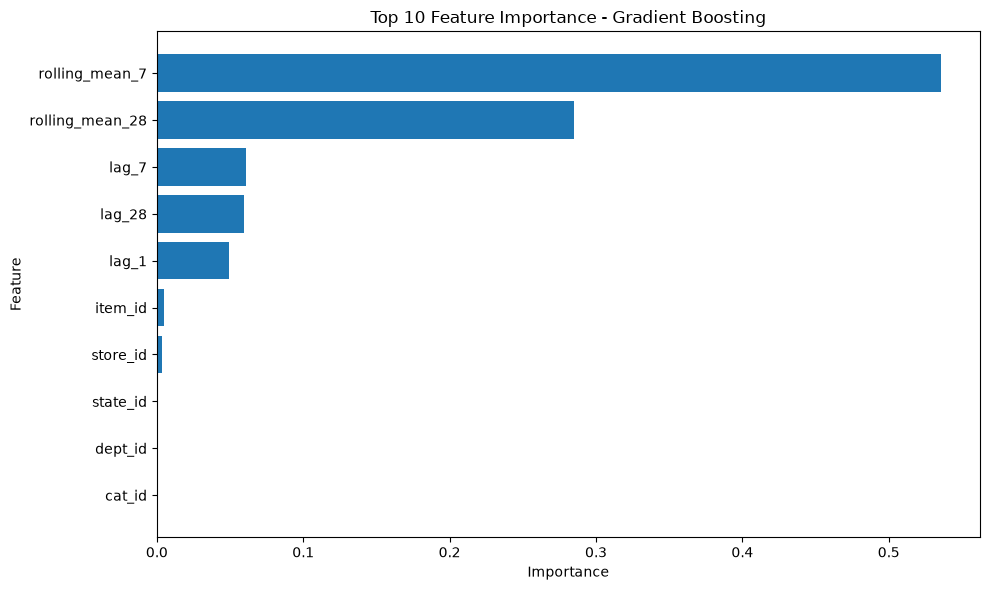

In [96]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Gradient Boosting")

plt.tight_layout()
plt.show()

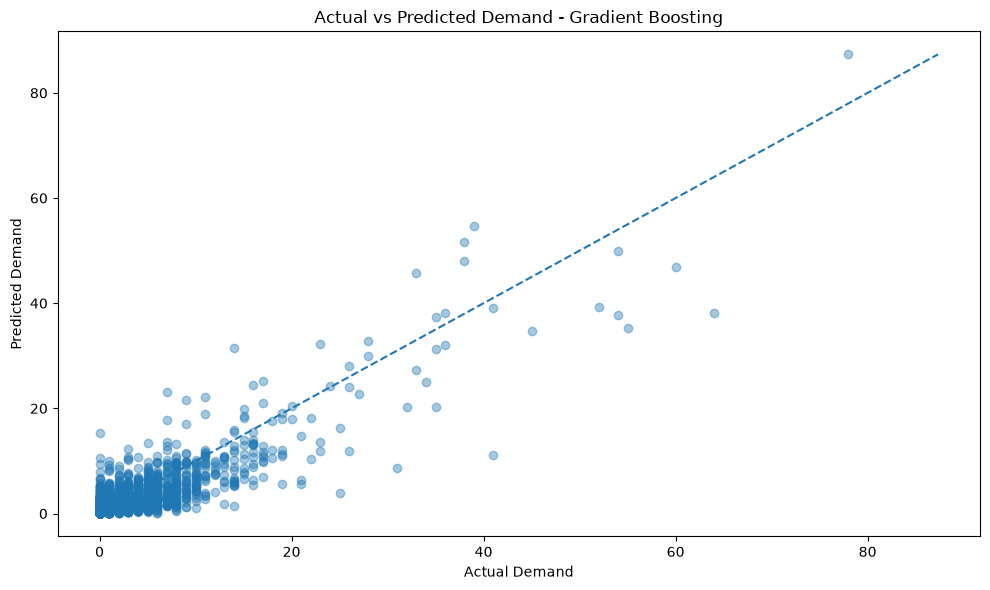

In [97]:
# ==========================================================
# Actual vs Predicted - Gradient Boosting
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_gb.min())
max_value = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand - Gradient Boosting")

plt.tight_layout()
plt.show()

In [98]:
import joblib

# Save the selected Gradient Boosting model
joblib.dump(gb_model, "gradient_boosting_demand_model.pkl")

print("Gradient Boosting model saved successfully!")

Gradient Boosting model saved successfully!


In [99]:
# Save the feature column order
joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

print("Model feature list saved successfully!")

Model feature list saved successfully!


In [100]:
import joblib

joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [ ]:
# Check the dataframes currently available
%whos DataFrame

Variable      Type         Data/Info
------------------------------------
calendar_df   DataFrame    Shape: (1969, 21)
prices_df     DataFrame    Shape: (6841121, 4)
sales_df      DataFrame    Shape: (30490, 1919)
